In [2]:
!pip install transformers datasets accelerate spacy textstat seaborn
!python -m spacy download ru_core_news_lg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 36.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.4/513.4 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 49.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
import pandas as pd
import numpy as np
import spacy
import textstat
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import torch
import re
from transformers import pipeline, AutoModelForSeq2SeqLM, AutoTokenizer

In [4]:
nlp = spacy.load("ru_core_news_lg")
device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Модель для определения домена
classifier = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
    device=0 if device == "cuda" else -1
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/mDeBERTa-v3-base-mnli-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

In [5]:
para_model_name = "cointegrated/rut5-base-paraphraser"
para_tokenizer = AutoTokenizer.from_pretrained(para_model_name)
para_model = AutoModelForSeq2SeqLM.from_pretrained(para_model_name).to(device)

def generate_paraphrase(text):
    """Функция для перефразирования текста"""
    inputs = para_tokenizer(text, return_tensors="pt", padding=True).to(device)
    outputs = para_model.generate(
        **inputs,
        max_length=150,
        num_beams=5,
        do_sample=True,
        top_k=50,
        temperature=0.7,
        encoder_no_repeat_ngram_size=4
    )
    return para_tokenizer.decode(outputs[0], skip_special_tokens=True)

config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/315 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/828k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/977M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [6]:
FILES = [
    "/content/aggregated_results_by_ds__pool_37806285__2023_02_18.tsv",
    "/content/aggregated_results_by_ds__pool_37939772__2023_02_27.tsv",
]

def parse_category(x):
    if pd.isna(x):
        return np.nan
    m = re.search(r"-?\d+", str(x))
    return int(m.group()) if m else np.nan

def parse_confidence(x):
    """ "100.00%" -> 100.0 """
    if pd.isna(x):
        return np.nan
    return float(str(x).replace("%", "").strip())

def load_one(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t")
    df = df.rename(columns={
        "INPUT:text": "text",
        "OUTPUT:category": "category_raw",
        "CONFIDENCE:category": "confidence_raw",
    })

    df["complexity"] = df["category_raw"].apply(parse_category)
    df["confidence"] = df["confidence_raw"].apply(parse_confidence)

    # чистка
    df = df.dropna(subset=["text", "complexity"]).copy()
    df["complexity"] = df["complexity"].astype(int)

    return df[["text", "complexity", "confidence"]]


# 1) читаем оба файла
dfs = [load_one(p) for p in FILES]

# 2) собираем в единый датасет
data = pd.concat(dfs, ignore_index=True)

In [7]:
data

,text,complexity,confidence
0,"Разглядывая их под микроскопом , мы увидим при...",4,100.0
1,"Иногда талантливые люди , не найдя себя в наук...",4,100.0
2,Кандидаты в депутаты от общественных организац...,6,100.0
3,"Главное , чтобы "" социальные лифты "" не остана...",6,100.0
4,Франция признает российских студентов и не при...,2,100.0
...,...,...,...
1195,В 1991 - 2008 чемпионками мира ( с перерывами ...,3,100.0
1196,То есть сейчас действительно уже можно получат...,5,100.0
1197,"Да и понятия "" параолимпийский тренер "" в обыд...",7,100.0
1198,Такое представление на длительное время заторм...,5,100.0


In [11]:
from tqdm.auto import tqdm
from transformers import pipeline

# Инициализируем пайплайн
classifier = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
    device=device
)

candidate_labels = [
    "Художественный стиль",                 # Романы, проза
    "Публицистический стиль",               # СМИ, новости, блоги
    "Официально-деловой стиль",             # Договоры, юриспруденция
    "Научный стиль",                        # Статьи, диссертации
    "Научно-популярный стиль",              # Научпоп (отделяем от сухой науки)
    "Инженерно-техническая документация",   # Авиация, энергетика, ГОСТы
    "Медицинская документация",             # Протоколы, инструкции к препаратам
    "ИТ-документация",                      # Спецификации, API
    "Справочно-энциклопедический",          # Словари, вики
    "Разговорный стиль"                     # Чаты, диалоги
]

print("Начинаем единую классификацию стилей и доменов (батчами)...")
texts = df['text'].tolist()
batch_size = 32
results = []

for i in tqdm(range(0, len(texts), batch_size), desc="Классификация текстов"):
    batch = texts[i:i+batch_size]
    res = classifier(batch, candidate_labels, multi_label=False)
    results.extend(res)

# Сохраняем результаты
df['domain'] = [r['labels'][0] for r in results]
df['style'] = [r['labels'][1] for r in results]
print("\nИтоговое распределение по стилям и доменам:")
print(df['domain'].value_counts())

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/mDeBERTa-v3-base-mnli-xnli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Начинаем единую классификацию стилей и доменов (батчами)...


Классификация текстов:   0%|          | 0/38 [00:00<?, ?it/s]


Итоговое распределение по стилям и доменам:
domain
Публицистический стиль                467
Разговорный стиль                     294
Официально-деловой стиль              243
Научный стиль                          72
Справочно-энциклопедический            49
Художественный стиль                   30
Научно-популярный стиль                20
ИТ-документация                        11
Медицинская документация               11
Инженерно-техническая документация      3
Name: count, dtype: int64


In [12]:
df

,text,complexity,confidence,domain
0,"Разглядывая их под микроскопом , мы увидим при...",4,100.0,Научно-популярный стиль
1,"Иногда талантливые люди , не найдя себя в наук...",4,100.0,Научный стиль
2,Кандидаты в депутаты от общественных организац...,6,100.0,Официально-деловой стиль
3,"Главное , чтобы "" социальные лифты "" не остана...",6,100.0,Публицистический стиль
4,Франция признает российских студентов и не при...,2,100.0,Разговорный стиль
...,...,...,...,...
1195,В 1991 - 2008 чемпионками мира ( с перерывами ...,3,100.0,Публицистический стиль
1196,То есть сейчас действительно уже можно получат...,5,100.0,Научный стиль
1197,"Да и понятия "" параолимпийский тренер "" в обыд...",7,100.0,Публицистический стиль
1198,Такое представление на длительное время заторм...,5,100.0,Медицинская документация


In [16]:
import random
import re
from tqdm.auto import tqdm
from transformers import pipeline
import torch

device_id = 0 if torch.cuda.is_available() else -1

print("Загрузка генеративной модели (ruGPT-3):")
generator = pipeline(
    "text-generation",
    model="ai-forever/rugpt3medium_based_on_gpt2",
    device=device_id
)

# Словарь. Модель будет использовать их как начало предложения
seed_phrases = {
    "Инженерно-техническая документация": [
        "При эксплуатации оборудования", "Монтаж установки должен",
        "Для предотвращения поломки", "Согласно требованиям ГОСТ",
        "Механизм состоит из", "Перед запуском двигателя"
    ],
    "Медицинская документация": [
        "Рекомендуемая дозировка препарата", "Противопоказания включают",
        "В ходе клинических исследований", "Для постановки диагноза",
        "У пациента наблюдались", "При внутривенном введении"
    ],
    "ИТ-документация": [
        "Для инициализации базы данных", "Данный метод API возвращает",
        "Архитектура микросервисов", "В случае возникновения критической ошибки",
        "Параметры функции включают", "Синтаксис запроса требует"
    ],
    "Научно-популярный стиль": [
        "Ученые выяснили, что", "Главная загадка этого явления",
        "В этой статье мы разберем", "Интересный факт заключается в",
        "Современная физика позволяет"
    ],
    "Художественный стиль": [
        "Ветер тихо шуршал", "Он внимательно посмотрел на",
        "Старый город спал", "Внезапно раздался", "Она наконец поняла, что"
    ],
    "Справочно-энциклопедический": [
        "Данный термин обозначает", "Исторически сложилось, что",
        "Основные характеристики включают", "Широко применяется в области"
    ],
    "Научный стиль": [
        "В данном исследовании", "Анализ полученных данных выявил",
        "Теоретическая значимость работы", "Методология эксперимента основана на"
    ]
}

def generate_new_sentence(domain):
    """Генерирует одно уникальное предложение для заданного домена"""
    seeds = seed_phrases.get(domain, ["В связи с этим", "Таким образом", "Важно отметить, что"])
    prompt = random.choice(seeds)

    # Генерируем текст
    out = generator(
        prompt,
        max_length=40,            # Длина в токенах (примерно одно-два предложения)
        num_return_sequences=1,
        temperature=0.85,         # Делаем текст разнообразным
        top_p=0.9,
        repetition_penalty=1.2,   # Штраф за повторение одних и тех же слов
        do_sample=True,
        truncation=True
    )
    text = out[0]['generated_text']

    text = text.replace('\n', ' ')
    match = re.search(r'[^.!?]*[.!?]', text)
    if match:
        sentence = match.group(0).strip()
    else:
        sentence = text.strip() + "."

    return re.sub(r'\s+', ' ', sentence)

print("\nПроверка дисбаланса и генерация НОВЫХ данных...")
MIN_SAMPLES_PER_DOMAIN = 100 # Целевое количество текстов
synthetic_data = []
domain_counts = df['domain'].value_counts()

for domain, count in domain_counts.items():
    if count < MIN_SAMPLES_PER_DOMAIN:
        needed = MIN_SAMPLES_PER_DOMAIN - count
        print(f"\nДомену '{domain}' не хватает {needed} примеров.")

        # Считаем среднюю когнитивную сложность для этого домена на основе реальных данных
        # Чтобы синтетические тексты наследовали реалистичную оценку
        if 'complexity' in df.columns:
            avg_complexity = df[df['domain'] == domain]['complexity'].mean()
            if pd.isna(avg_complexity): avg_complexity = 3.0 # Дефолт
        else:
            avg_complexity = np.nan

        for i in tqdm(range(needed), desc=f"Генерация {domain[:15]}"):
            # Вызываем нашу генеративную функцию
            syn_text = generate_new_sentence(domain)

            synthetic_data.append({
                "text": syn_text,
                "domain": domain,
                "complexity": avg_complexity,
                "is_synthetic": True
            })

Загрузка генеративной модели (ruGPT-3):


config.json:   0%|          | 0.00/761 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.73G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.73G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

...


Домену 'Инженерно-техническая документация' не хватает 97 примеров.


Генерация Инженерно-техни:   0%|          | 0/97 [00:00<?, ?it/s]

Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both


Считаем лингвистические метрики для сгенерированных текстов...


NameError: name 'calculate_metrics' is not defined

In [18]:
df_syn

,text,domain,complexity,is_synthetic
0,В данном исследовании мы использовали метод ко...,Научный стиль,5.194444,True
1,Методология эксперимента основана на использов...,Научный стиль,5.194444,True
2,"В данном исследовании, результаты которого был...",Научный стиль,5.194444,True
3,Методология эксперимента основана на использов...,Научный стиль,5.194444,True
4,Теоретическая значимость работы.,Научный стиль,5.194444,True
...,...,...,...,...
499,"При эксплуатации оборудования, предназначенног...",Инженерно-техническая документация,6.000000,True
500,"Перед запуском двигателя в цехе, который наход...",Инженерно-техническая документация,6.000000,True
501,"Перед запуском двигателя самолет-разведчик, ко...",Инженерно-техническая документация,6.000000,True
502,Механизм состоит из следующих элементов: 1.,Инженерно-техническая документация,6.000000,True


In [19]:
# 2. метрики
textstat.set_lang("ru")

def calculate_metrics(text):
    doc = nlp(text)

    dists = [abs(t.i - t.head.i) for t in doc if t.head != t]
    mdd = np.mean(dists) if dists else 0

    clauses = sum(1 for t in doc if t.pos_ in {"VERB", "AUX"} and t.dep_ in {"ROOT", "ccomp", "xcomp", "advcl", "acl", "relcl"})

    return pd.Series({
        "flesch_reading_ease": textstat.flesch_reading_ease(text),
        "mdd_syntactic_complexity": mdd,
        "num_clauses": clauses,
        "sentence_length": len(doc)
    })

In [20]:
if synthetic_data:
    df_syn = pd.DataFrame(synthetic_data)

    # Расчет лингвистических метрик (MDD, Flesch) для новых текстов
    print("\nСчитаем лингвистические метрики для сгенерированных текстов...")
    tqdm.pandas(desc="Метрики")
    df_syn_metrics = df_syn['text'].progress_apply(calculate_metrics)
    df_syn = pd.concat([df_syn, df_syn_metrics], axis=1)

    # Объединяем с основным датасетом
    df['is_synthetic'] = False
    df = pd.concat([df, df_syn], ignore_index=True)
else:
    df['is_synthetic'] = False

print("Новое распределение по доменам:")
print(df['domain'].value_counts())


Считаем лингвистические метрики для сгенерированных текстов...


Метрики:   0%|          | 0/504 [00:00<?, ?it/s]

Новое распределение по доменам:
domain
Публицистический стиль                467
Разговорный стиль                     294
Официально-деловой стиль              243
Научно-популярный стиль               100
Научный стиль                         100
Художественный стиль                  100
Справочно-энциклопедический           100
ИТ-документация                       100
Медицинская документация              100
Инженерно-техническая документация    100
Name: count, dtype: int64


In [22]:
df.head()

,text,complexity,confidence,domain,is_synthetic,flesch_reading_ease,mdd_syntactic_complexity,num_clauses,sentence_length
0,"Разглядывая их под микроскопом , мы увидим при...",4.0,100.0,Научно-популярный стиль,False,NaN,NaN,NaN,NaN
1,"Иногда талантливые люди , не найдя себя в наук...",4.0,100.0,Научный стиль,False,NaN,NaN,NaN,NaN
2,Кандидаты в депутаты от общественных организац...,6.0,100.0,Официально-деловой стиль,False,NaN,NaN,NaN,NaN
3,"Главное , чтобы "" социальные лифты "" не остана...",6.0,100.0,Публицистический стиль,False,NaN,NaN,NaN,NaN
4,Франция признает российских студентов и не при...,2.0,100.0,Разговорный стиль,False,NaN,NaN,NaN,NaN


In [23]:
import textstat
from tqdm.auto import tqdm

tqdm.pandas(desc="Расчет метрик")
textstat.set_lang("ru")

def final_calculate_metrics(text):
    """
    Расширенная функция расчета метрик с обработкой исключений
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return pd.Series({
            "flesch_reading_ease": 0,
            "mdd_syntactic_complexity": 0,
            "num_clauses": 0,
            "sentence_length": 0
        })

    try:
        doc = nlp(text)

        # 1. MDD (Mean Dependency Distance)
        dists = [abs(t.i - t.head.i) for t in doc if t.head != t]
        mdd = np.mean(dists) if dists else 0

        # 2. Количество клауз (полипредикативность)
        # Ищем глаголы, которые являются вершинами предикативных частей
        clauses = sum(1 for t in doc if t.pos_ in {"VERB", "AUX"} and
                     t.dep_ in {"ROOT", "ccomp", "xcomp", "advcl", "acl", "relcl", "parataxis"})

        return pd.Series({
            "flesch_reading_ease": textstat.flesch_reading_ease(text),
            "mdd_syntactic_complexity": mdd,
            "num_clauses": clauses,
            "sentence_length": len(doc)
        })
    except Exception as e:
        return pd.Series({
            "flesch_reading_ease": 0,
            "mdd_syntactic_complexity": 0,
            "num_clauses": 0,
            "sentence_length": 0
        })

# --- ЗАПУСК РАСЧЕТА ---
print(f"Начинаю расчет метрик для {len(df)} строк...")

# Применяем расчет ко всему датафрейму
metrics_results = df['text'].progress_apply(final_calculate_metrics)

# Объединяем (если колонки уже были, сначала удалим их, чтобы не дублировать)
cols_to_drop = ["flesch_reading_ease", "mdd_syntactic_complexity", "num_clauses", "sentence_length"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
df = pd.concat([df, metrics_results], axis=1)

# --- АГРЕГАЦИЯ И ВЫВОД СТАТИСТИКИ ---
print("\n" + "="*50)
print("ИТОГОВАЯ СТАТИСТИКА ПО ДОМЕНАМ")
print("="*50)

domain_stats = df.groupby('domain').agg({
    'text': 'count',
    'mdd_syntactic_complexity': 'mean',
    'num_clauses': 'mean',
    'flesch_reading_ease': 'mean',
    'sentence_length': 'mean'
}).rename(columns={'text': 'count'}).sort_values(by='mdd_syntactic_complexity', ascending=False)

print(domain_stats.round(2))
df.to_csv("processed_cognitive_dataset.csv", index=False)
print("\nДатасет сохранен в 'processed_cognitive_dataset.csv'")

Начинаю расчет метрик для 1704 строк...


Расчет метрик:   0%|          | 0/1704 [00:00<?, ?it/s]


ИТОГОВАЯ СТАТИСТИКА ПО ДОМЕНАМ
                                    count  mdd_syntactic_complexity  \
domain                                                                
Разговорный стиль                     294                      3.37   
Научный стиль                         100                      3.33   
Публицистический стиль                467                      3.21   
Справочно-энциклопедический           100                      3.16   
Официально-деловой стиль              243                      3.15   
Научно-популярный стиль               100                      3.13   
ИТ-документация                       100                      3.00   
Медицинская документация              100                      2.88   
Инженерно-техническая документация    100                      2.76   
Художественный стиль                  100                      2.58   

                                    num_clauses  flesch_reading_ease  \
domain                                     

In [25]:
tqdm.pandas(desc="Глубокий анализ метрик")

def final_calculate_metrics(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return pd.Series()

    try:
        doc = nlp(text)

        # --- СИНТАКСИЧЕСКИЕ МЕТРИКИ (MDD) ---
        dists = [abs(t.i - t.head.i) for t in doc if t.head != t]

        mdd_avg = np.mean(dists) if dists else 0
        mdd_max = np.max(dists) if dists else 0
        mdd_sum = np.sum(dists) if dists else 0

        # Предикативность (количество клауз)
        clauses = sum(1 for t in doc if t.pos_ in {"VERB", "AUX"} and
                     t.dep_ in {"ROOT", "ccomp", "xcomp", "advcl", "acl", "relcl", "parataxis"})

        # --- ИНДЕКСЫ УДОБОЧИТАЕМОСТИ (Русские адаптации) ---
        return pd.Series({
            # Синтаксис
            "mdd_avg": mdd_avg,
            "mdd_max": mdd_max,
            "mdd_sum": mdd_sum,
            "num_clauses": clauses,

            # Читабельность (традиционные)
            "FLESru": textstat.flesch_reading_ease(text),       # Индекс удобочитаемости Флеша
            "FKGLru": textstat.flesch_kincaid_grade(text),     # Уровень сложности Флеша-Кинкейда
            "SMOGru": textstat.smog_index(text),               # Индекс SMOG
            "ARIru": textstat.automated_readability_index(text),# Автоматический индекс удобочитаемости

            # Дополнительно: Информационная плотность
            "noun_ratio": sum(1 for t in doc if t.pos_ == "NOUN") / len(doc) if len(doc) > 0 else 0,
            "avg_word_len": np.mean([len(t.text) for t in doc if not t.is_punct]) if len(doc) > 0 else 0
        })
    except Exception:
        return pd.Series()

# --- ЗАПУСК ---
print(f"Рассчитываем расширенные метрики для {len(df)} текстов...")
new_metrics = df['text'].progress_apply(final_calculate_metrics)

# Удаляем старые колонки если они были и джойним новые
df = df.drop(columns=[c for c in new_metrics.columns if c in df.columns])
df = pd.concat([df, new_metrics], axis=1)

# --- ПРОВЕРКА ГИПОТЕЗЫ ---
# Сравним технические домены с художественным и разговорным
target_domains = [
    "Инженерно-техническая документация",
    "Медицинская документация",
    "ИТ-документация",
    "Художественный стиль",
    "Разговорный стиль"
]

print("\n" + "="*70)
print("СРАВНИТЕЛЬНЫЙ АНАЛИЗ КОГНИТИВНОЙ СЛОЖНОСТИ ПО ДОМЕНАМ")
print("="*70)

comparison = df[df['domain'].isin(target_domains)].groupby('domain').agg({
    'mdd_max': 'mean',        # Пиковая когнитивная нагрузка
    'num_clauses': 'mean',    # Полипредикативность
    'FLESru': 'mean',         # Легкость чтения (чем ниже, тем сложнее)
    'noun_ratio': 'mean'      # Плотность терминов (существительных)
}).sort_values(by='mdd_max', ascending=False)

print(comparison.round(3))

Рассчитываем расширенные метрики для 1704 текстов...


Глубокий анализ метрик:   0%|          | 0/1704 [00:00<?, ?it/s]


СРАВНИТЕЛЬНЫЙ АНАЛИЗ КОГНИТИВНОЙ СЛОЖНОСТИ ПО ДОМЕНАМ
                                    mdd_max  num_clauses  FLESru  noun_ratio
domain                                                                      
Разговорный стиль                    18.017        1.701  54.634       0.218
ИТ-документация                      13.950        1.180  29.013       0.374
Инженерно-техническая документация   13.800        1.140  27.590       0.360
Медицинская документация             13.520        0.860  22.198       0.391
Художественный стиль                  8.890        1.370  71.612       0.191


/tmp/ipykernel_1892/2423694229.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='mdd_max', y='domain', order=order, palette='flare')


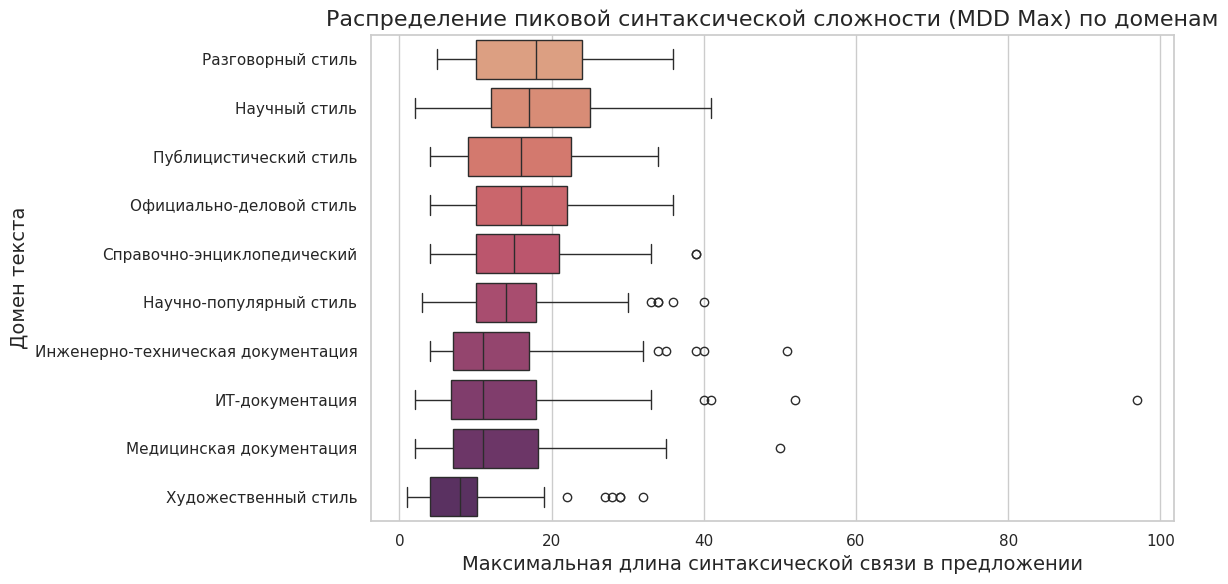

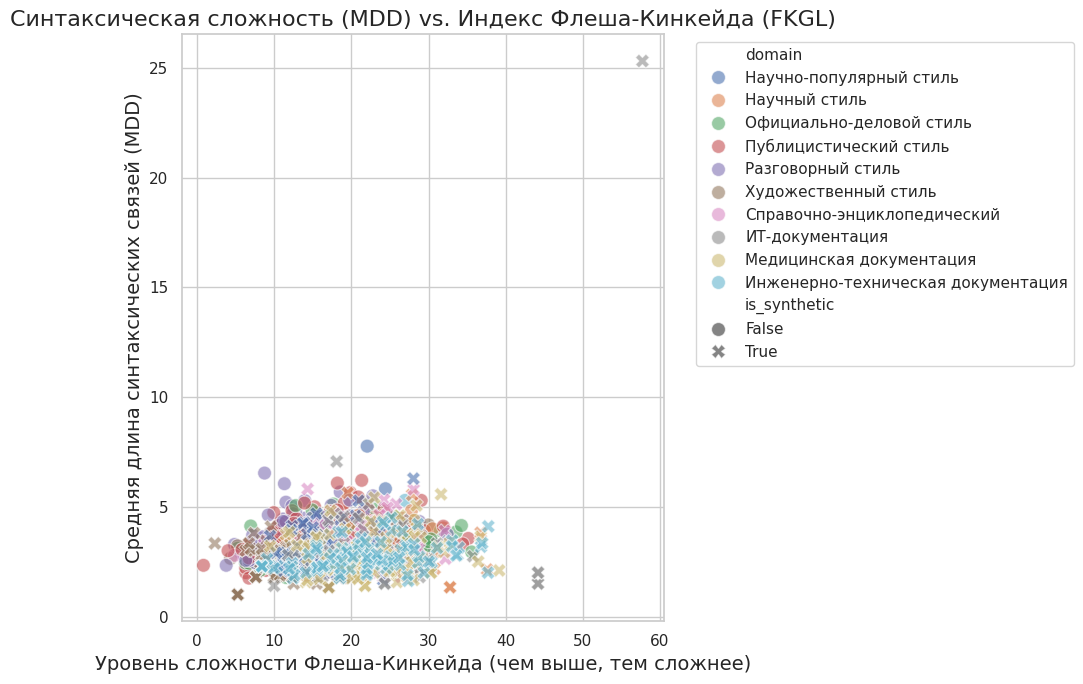

/tmp/ipykernel_1892/2423694229.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_noun, x='noun_ratio', y='domain', palette='viridis')


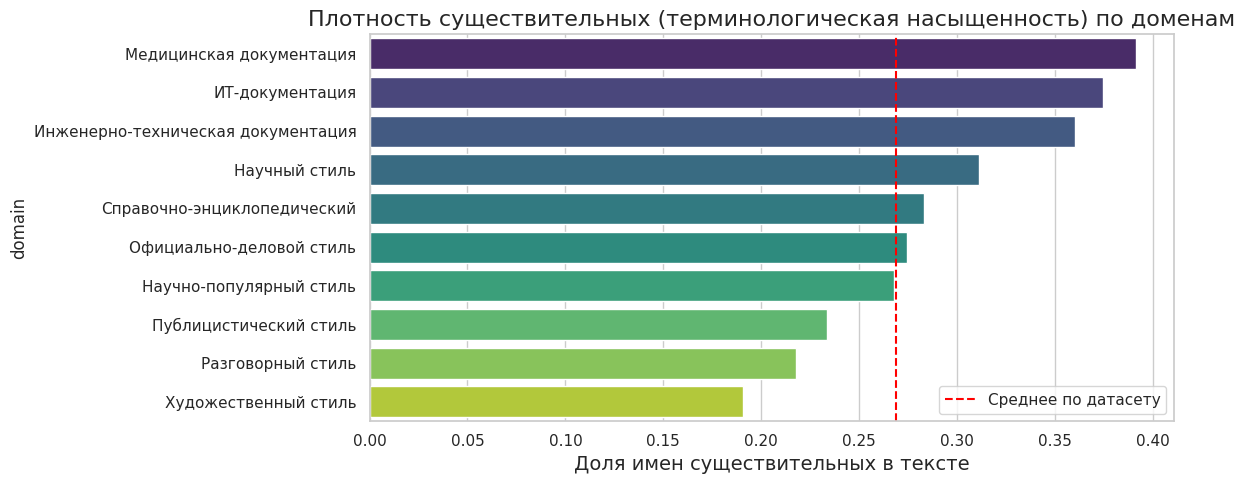

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 12

plt.figure(figsize=(12, 6))
order = df.groupby('domain')['mdd_max'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='mdd_max', y='domain', order=order, palette='flare')
plt.title('Распределение пиковой синтаксической сложности (MDD Max) по доменам', fontsize=16)
plt.xlabel('Максимальная длина синтаксической связи в предложении', fontsize=14)
plt.ylabel('Домен текста', fontsize=14)
plt.tight_layout()
plt.savefig('mdd_max_distribution.png', dpi=300)
plt.show()

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='FKGLru', y='mdd_avg', hue='domain', style='is_synthetic', alpha=0.6, s=100)
plt.title('Синтаксическая сложность (MDD) vs. Индекс Флеша-Кинкейда (FKGL)', fontsize=16)
plt.xlabel('Уровень сложности Флеша-Кинкейда (чем выше, тем сложнее)', fontsize=14)
plt.ylabel('Средняя длина синтаксических связей (MDD)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('syntax_vs_readability.png', dpi=300)
plt.show()

plt.figure(figsize=(12, 5))
avg_noun = df.groupby('domain')['noun_ratio'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=avg_noun, x='noun_ratio', y='domain', palette='viridis')
plt.axvline(df['noun_ratio'].mean(), color='red', linestyle='--', label='Среднее по датасету')
plt.title('Плотность существительных (терминологическая насыщенность) по доменам', fontsize=16)
plt.xlabel('Доля имен существительных в тексте', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('noun_density.png', dpi=300)
plt.show()

/tmp/ipykernel_1892/2099919124.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


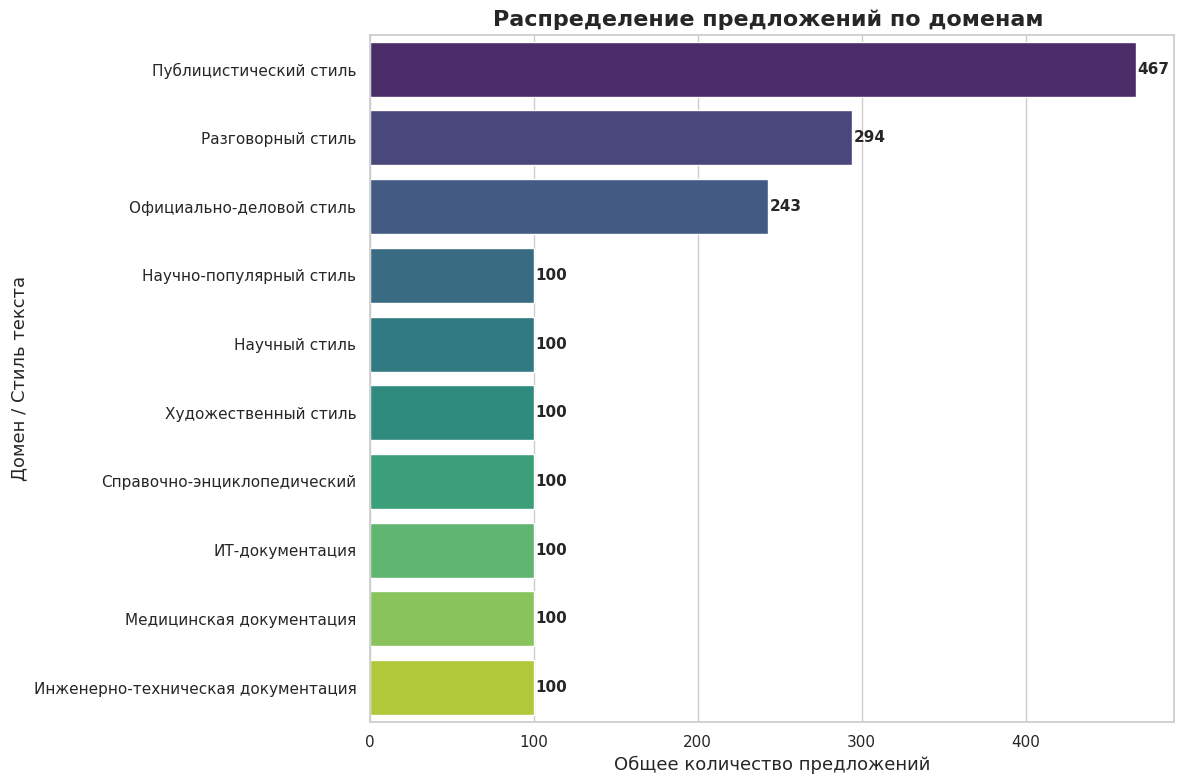

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

domain_counts = df['domain'].value_counts().reset_index()
domain_counts.columns = ['domain', 'total_count']

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

sns.barplot(
    data=domain_counts,
    y='domain',
    x='total_count',
    palette='viridis'
)

plt.title('Распределение предложений по доменам ', fontsize=16, fontweight='bold')
plt.xlabel('Общее количество предложений', fontsize=13)
plt.ylabel('Домен / Стиль текста', fontsize=13)

for i, count in enumerate(domain_counts['total_count']):
    plt.text(count + 1, i, str(int(count)), va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('domain_distribution_total.png', dpi=300)
plt.show()

In [28]:
import pandas as pd
from scipy.stats import chisquare

counts = df['domain'].value_counts().values

# 1. Считаем Imbalance Ratio (IR)
ir = counts.max() / counts.min()
print(f"Коэффициент дисбаланса (IR): {ir:.2f}")

# 2. Тест Хи-квадрат
# Ожидаемое количество - если бы все классы были равны (среднее значение)
expected_counts = [counts.mean()] * len(counts)

chi2_stat, p_value = chisquare(f_obs=counts, f_exp=expected_counts)

print(f"Хи-квадрат статистика: {chi2_stat:.2f}")
print(f"P-значение: {p_value:.5e}")

if p_value < 0.05:
    print("\nВывод: Отвергаем нулевую гипотезу. Распределение классов статистически значимо несбалансировано.")
    print("Применение методов генерации/аугментации строго обосновано.")
else:
    print("\nВывод: Классы сбалансированы.")

Коэффициент дисбаланса (IR): 4.67
Хи-квадрат статистика: 840.45
P-значение: 4.16027e-175

Вывод: Отвергаем нулевую гипотезу. Распределение классов статистически значимо несбалансировано.
Применение методов генерации/аугментации строго обосновано.


In [29]:
TARGET_COUNT = 100

# Создаем пустой список для сбалансированных кусочков
balanced_dfs = []

for domain in df['domain'].unique():
    domain_df = df[df['domain'] == domain]

    if len(domain_df) > TARGET_COUNT:
        domain_df = domain_df.sample(n=TARGET_COUNT, random_state=42)

    balanced_dfs.append(domain_df)

# Собираем всё обратно
df_balanced = pd.concat(balanced_dfs, ignore_index=True)

print("Распределение после обрезки больших классов:")
print(df_balanced['domain'].value_counts())

Распределение после обрезки больших классов:
domain
Научно-популярный стиль               100
Научный стиль                         100
Официально-деловой стиль              100
Публицистический стиль                100
Разговорный стиль                     100
Художественный стиль                  100
Справочно-энциклопедический           100
ИТ-документация                       100
Медицинская документация              100
Инженерно-техническая документация    100
Name: count, dtype: int64


In [31]:
df = df_balanced
counts = df['domain'].value_counts().values

# 1. Считаем Imbalance Ratio (IR)
ir = counts.max() / counts.min()
print(f"Коэффициент дисбаланса (IR): {ir:.2f}")

# 2. Тест Хи-квадрат
# Ожидаемое количество - если бы все классы были равны (среднее значение)
expected_counts = [counts.mean()] * len(counts)

chi2_stat, p_value = chisquare(f_obs=counts, f_exp=expected_counts)

print(f"Хи-квадрат статистика: {chi2_stat:.2f}")
print(f"P-значение: {p_value:.5e}")

if p_value < 0.05:
    print("\nВывод: Отвергаем нулевую гипотезу. Распределение классов статистически значимо несбалансировано.")
    print("Применение методов генерации/аугментации строго обосновано.")
else:
    print("\nВывод: Классы сбалансированы.")

Коэффициент дисбаланса (IR): 1.00
Хи-квадрат статистика: 0.00
P-значение: 1.00000e+00

Вывод: Классы сбалансированы.


/tmp/ipykernel_1892/621286003.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


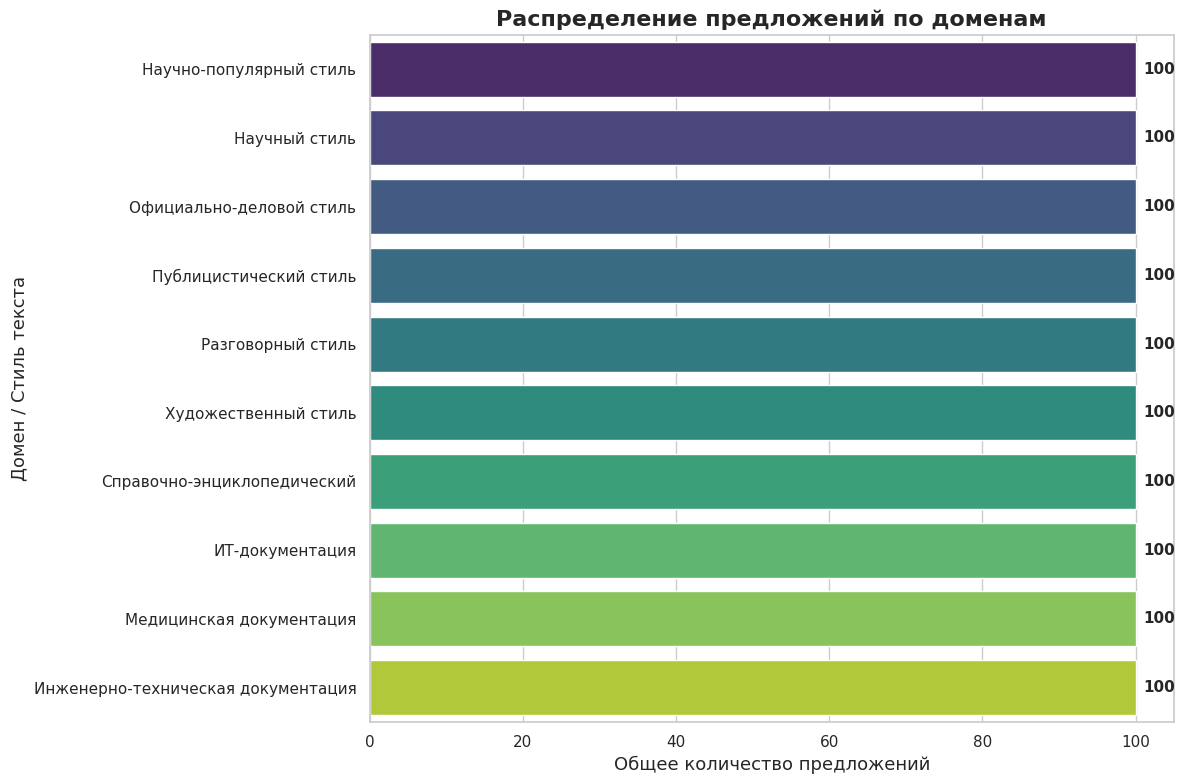

In [32]:
domain_counts = df['domain'].value_counts().reset_index()
domain_counts.columns = ['domain', 'total_count']

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

sns.barplot(
    data=domain_counts,
    y='domain',
    x='total_count',
    palette='viridis'
)

plt.title('Распределение предложений по доменам', fontsize=16, fontweight='bold')
plt.xlabel('Общее количество предложений', fontsize=13)
plt.ylabel('Домен / Стиль текста', fontsize=13)

for i, count in enumerate(domain_counts['total_count']):
    plt.text(count + 1, i, str(int(count)), va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('domain_distribution_total.png', dpi=300)
plt.show()

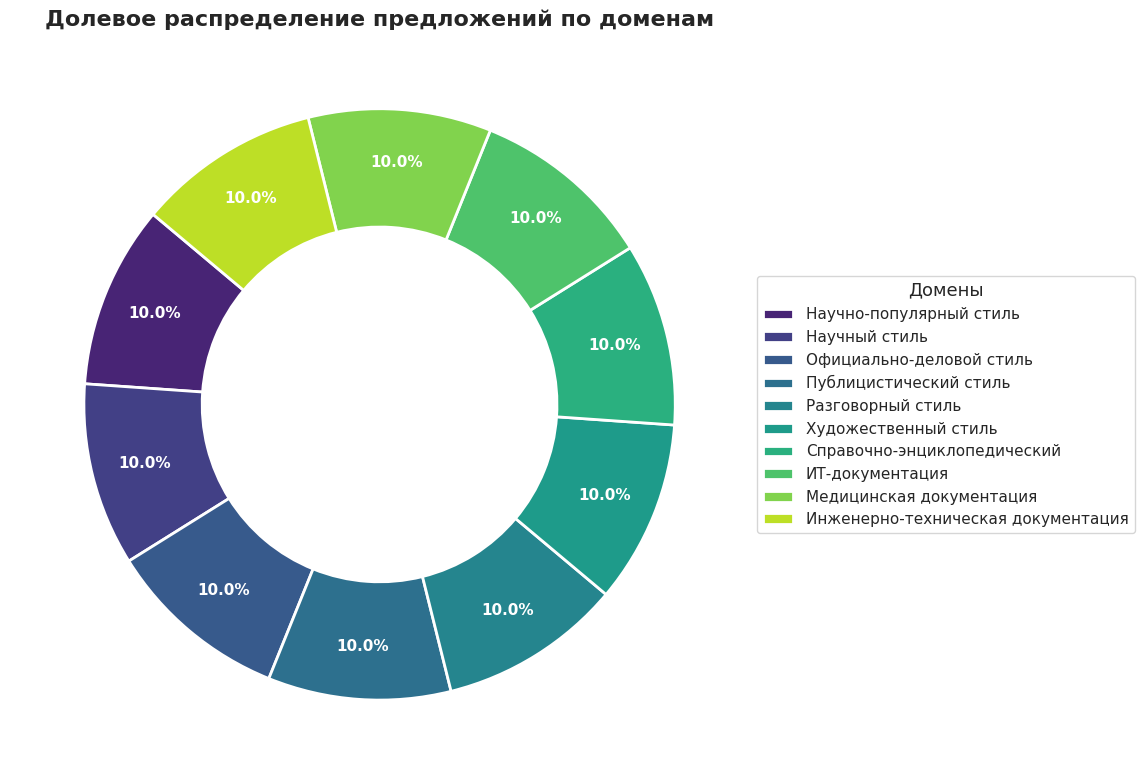

In [34]:
# 1. Подготовка данных
domain_counts = df['domain'].value_counts().reset_index()
domain_counts.columns = ['domain', 'total_count']

# 2. Настройка графика
fig, ax = plt.subplots(figsize=(12, 8))

# Генерируем цвета из палитры viridis (отступаем от краев 0.1 и 0.9, чтобы не было слишком светлых/темных)
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(domain_counts)))

# 3. Построение диаграммы-пончика (Donut Chart)
wedges, texts, autotexts = ax.pie(
    domain_counts['total_count'],
    autopct='%1.1f%%',       # Показывать проценты с одним знаком после запятой
    startangle=140,          # Поворачиваем график для красивого ракурса
    colors=colors,
    pctdistance=0.82,        # Сдвигаем цифры процентов ближе к внешнему краю
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2) # Делаем дырку внутри (width) и белые границы
)

# Делаем текст процентов жирным и более читаемым
plt.setp(autotexts, size=11, weight="bold", color="white")

# 4. Оформление
ax.set_title('Долевое распределение предложений по доменам', fontsize=16, fontweight='bold')

# Выносим длинные названия доменов в легенду сбоку (вместе с абсолютными числами)
legend_labels = [f"{row['domain']}" for idx, row in domain_counts.iterrows()]
ax.legend(
    wedges,
    legend_labels,
    title="Домены",
    title_fontsize=13,
    fontsize=11,
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1) # Сдвигаем легенду за пределы круга
)

# Сохраняем с параметром bbox_inches='tight', чтобы легенда не обрезалась
plt.tight_layout()
plt.savefig('domain_distribution_donut.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1892/2626081939.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='mdd_max', y='domain', order=order, palette='flare')


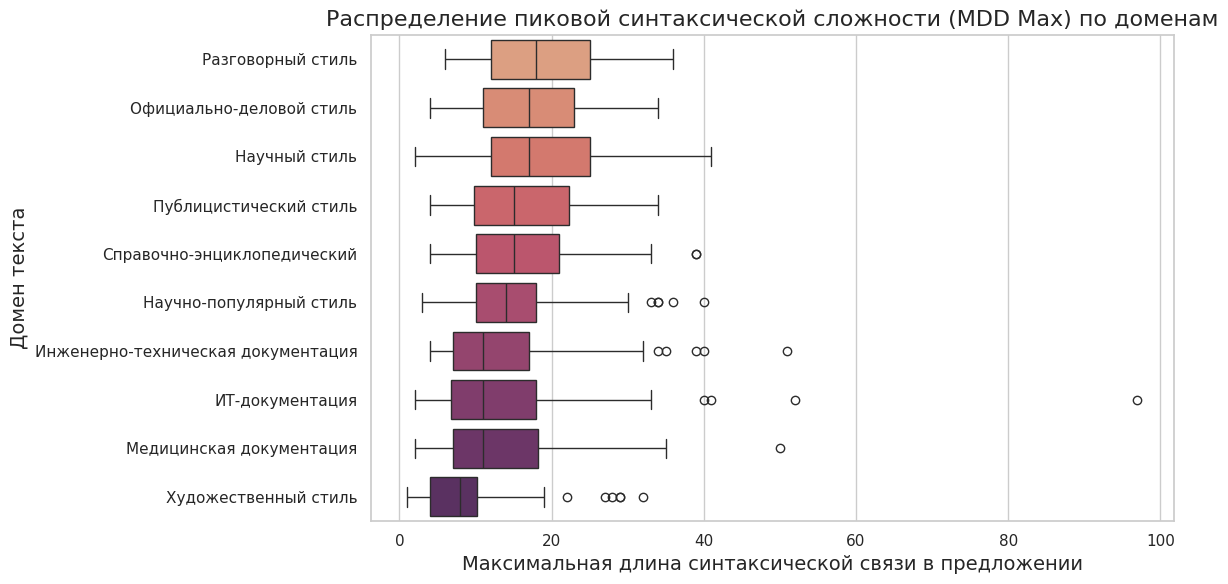

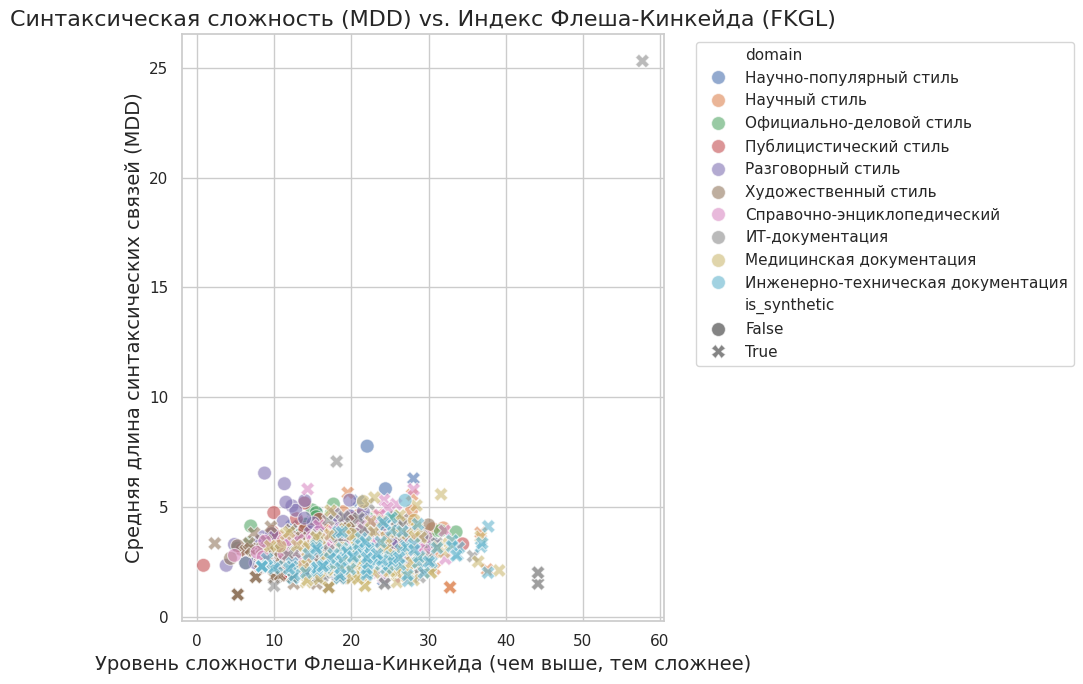

/tmp/ipykernel_1892/2626081939.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_noun, x='noun_ratio', y='domain', palette='viridis')


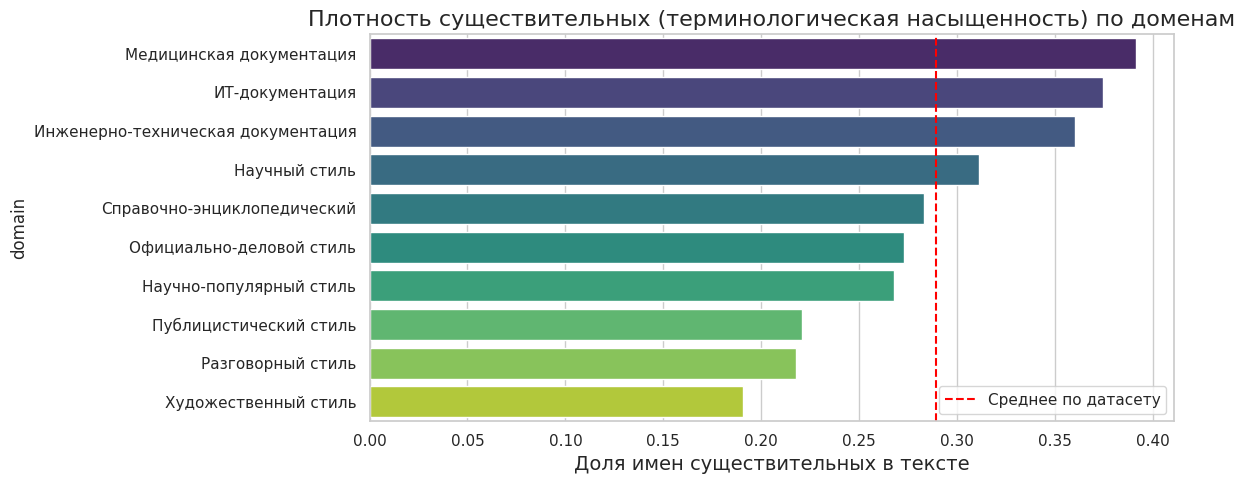

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 12

plt.figure(figsize=(12, 6))
order = df.groupby('domain')['mdd_max'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='mdd_max', y='domain', order=order, palette='flare')
plt.title('Распределение пиковой синтаксической сложности (MDD Max) по доменам', fontsize=16)
plt.xlabel('Максимальная длина синтаксической связи в предложении', fontsize=14)
plt.ylabel('Домен текста', fontsize=14)
plt.tight_layout()
plt.savefig('mdd_max_distribution.png', dpi=300)
plt.show()

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='FKGLru', y='mdd_avg', hue='domain', style='is_synthetic', alpha=0.6, s=100)
plt.title('Синтаксическая сложность (MDD) vs. Индекс Флеша-Кинкейда (FKGL)', fontsize=16)
plt.xlabel('Уровень сложности Флеша-Кинкейда (чем выше, тем сложнее)', fontsize=14)
plt.ylabel('Средняя длина синтаксических связей (MDD)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('syntax_vs_readability.png', dpi=300)
plt.show()

plt.figure(figsize=(12, 5))
avg_noun = df.groupby('domain')['noun_ratio'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=avg_noun, x='noun_ratio', y='domain', palette='viridis')
plt.axvline(df['noun_ratio'].mean(), color='red', linestyle='--', label='Среднее по датасету')
plt.title('Плотность существительных (терминологическая насыщенность) по доменам', fontsize=16)
plt.xlabel('Доля имен существительных в тексте', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('noun_density.png', dpi=300)
plt.show()

In [37]:
df.head()

,text,complexity,confidence,domain,is_synthetic,flesch_reading_ease,mdd_syntactic_complexity,sentence_length,mdd_avg,mdd_max,mdd_sum,num_clauses,FLESru,FKGLru,SMOGru,ARIru,noun_ratio,avg_word_len
0,"Разглядывая их под микроскопом , мы увидим при...",4.0,100.0,Научно-популярный стиль,False,45.610000,4.291667,25.0,4.291667,18.0,103.0,2.0,45.610000,18.760000,20.267339,10.236000,0.360000,5.500000
1,"Это вопросы не к ЕГЭ как таковому , а к качест...",3.0,100.0,Научно-популярный стиль,False,49.879444,3.263158,20.0,3.263158,18.0,62.0,0.0,49.879444,17.652222,19.287187,9.236000,0.300000,5.000000
2,Основные исследования лаборатории сфокусирован...,4.0,100.0,Научно-популярный стиль,False,-8.857308,2.857143,15.0,2.857143,11.0,40.0,1.0,-8.857308,28.510769,19.287187,18.668000,0.466667,8.076923
3,Общественный прогресс настоятельно требует соо...,7.0,100.0,Научно-популярный стиль,False,-9.673333,3.000000,30.0,3.000000,26.0,87.0,2.0,-9.673333,30.153333,25.980085,22.441000,0.266667,8.208333
4,"Отметим , что Siemens - рекордсмен и по тишине...",7.0,100.0,Научно-популярный стиль,False,33.727593,7.764706,35.0,7.764706,34.0,264.0,3.0,33.727593,22.036296,23.726700,15.081714,0.342857,6.037037


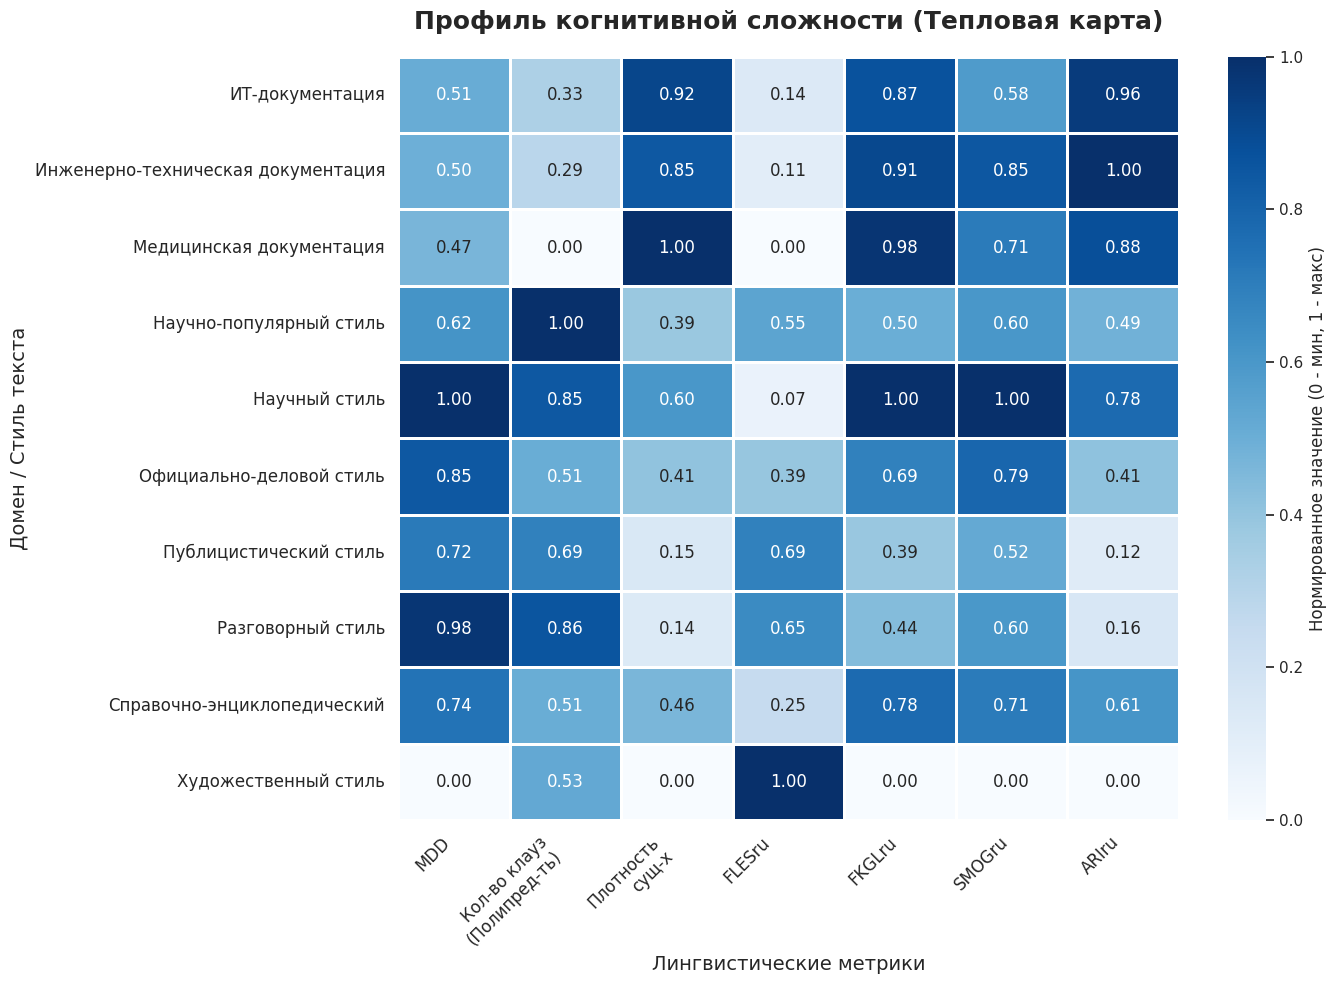

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

metrics = ['mdd_max', 'num_clauses', 'noun_ratio', 'FLESru', 'FKGLru', 'SMOGru', 'ARIru']
labels = ['MDD', 'Кол-во клауз\n(Полипред-ть)',
          'Плотность\nсущ-х', 'FLESru\n', 'FKGLru', 'SMOGru', 'ARIru']

# 1. Считаем средние значения
radar_data = df.groupby('domain')[metrics].mean()

# 2. Нормализуем данные от 0 до 1, чтобы разные шкалы можно было сравнивать цветом
scaler = MinMaxScaler()
heatmap_data = pd.DataFrame(
    scaler.fit_transform(radar_data),
    columns=labels,
    index=radar_data.index
)

# 3. Настройка и отрисовка тепловой карты
plt.figure(figsize=(14, 10))
sns.set_style("white")

# Используем палитру, где синий - минимум (0), а красный - максимум (1)
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=1,
    cbar_kws={'label': 'Нормированное значение (0 - мин, 1 - макс)'}
)

plt.title('Профиль когнитивной сложности (Тепловая карта)', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Домен / Стиль текста', fontsize=14)
plt.xlabel('Лингвистические метрики', fontsize=14)

# Поворачиваем подписи снизу для читабельности
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.savefig('cognitive_complexity_heatmap.png', dpi=300)
plt.show()

In [59]:
from scipy import stats

# 1. Формируем две группы для сравнения
tech_domains = ["Инженерно-техническая документация",
                "Медицинская документация",
                "ИТ-документация"
                ,"Научный стиль"
                ,"Справочно-энциклопедический"
                ]
simple_domains = ["Художественный стиль", "Разговорный стиль"]

# Вытаскиваем значения нашей главной метрики (например, mdd_max)
tech_mdd = df[df['domain'].isin(tech_domains)]['ARIru'].dropna()
simple_mdd = df[df['domain'].isin(simple_domains)]['ARIru'].dropna()


stat, p_value = stats.mannwhitneyu(tech_mdd, simple_mdd, alternative='greater')

print(f"U-статистика Манна-Уитни: {stat}")
print(f"P-значение (p-value): {p_value:.5e}")

if p_value < 0.05:
    print("✅ Вывод: Отвергаем нулевую гипотезу. Техническая документация СТАТИСТИЧЕСКИ ЗНАЧИМО сложнее.")
else:
    print("❌ Вывод: Разница статистически не значима.")

# 3. Считаем размер эффекта (d Коэна)
def cohen_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    # Объединенная дисперсия
    pooled_var = ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)
    d = (np.mean(group1) - np.mean(group2)) / np.sqrt(pooled_var)
    return d

d_effect = cohen_d(tech_mdd, simple_mdd)
print(f"\nРазмер эффекта (Cohen's d): {d_effect:.2f}")

if d_effect > 0.8:
    print("Оценка эффекта: СИЛЬНЫЙ (Огромная практическая разница)")
elif d_effect > 0.5:
    print("Оценка эффекта: СРЕДНИЙ (Заметная разница)")
else:
    print("Оценка эффекта: СЛАБЫЙ (Разница есть, но небольшая)")

U-статистика Манна-Уитни: 82901.5
P-значение (p-value): 1.68468e-42
✅ Вывод: Отвергаем нулевую гипотезу. Техническая документация СТАТИСТИЧЕСКИ ЗНАЧИМО сложнее.

Размер эффекта (Cohen's d): 1.23
Оценка эффекта: СИЛЬНЫЙ (Огромная практическая разница)


In [63]:
import pandas as pd
import numpy as np
from scipy import stats

# 1. Формируем две группы (Расширенные)
tech_domains = [
    "Инженерно-техническая документация",
    "Медицинская документация",
    "ИТ-документация",
    "Научный стиль",
    "Справочно-энциклопедический"
]
simple_domains = ["Художественный стиль", "Разговорный стиль"]

# Список всех лингвистических метрик, которые мы считали
metrics = ['mdd_max', 'num_clauses', 'noun_ratio', 'FLESru', 'FKGLru', 'SMOGru', 'ARIru']

# Функция для расчета d Коэна
def cohen_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_var = ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)
    d = (np.mean(group1) - np.mean(group2)) / np.sqrt(pooled_var)
    return d

# Список для сбора результатов
results = []

for metric in metrics:
    if metric not in df.columns:
        continue

    # Вытаскиваем значения
    tech_data = df[df['domain'].isin(tech_domains)][metric].dropna()
    simple_data = df[df['domain'].isin(simple_domains)][metric].dropna()

    # U-тест Манна-Уитни (Двусторонний, так как метрики могут работать в разные стороны)
    stat, p_value = stats.mannwhitneyu(tech_data, simple_data, alternative='two-sided')

    # Считаем размер эффекта
    d_val = cohen_d(tech_data, simple_data)
    abs_d = abs(d_val) # Берем модуль для оценки силы

    # Оцениваем силу эффекта
    if abs_d > 0.8: effect = "СИЛЬНЫЙ"
    elif abs_d > 0.5: effect = "СРЕДНИЙ"
    elif abs_d > 0.2: effect = "СЛАБЫЙ"
    else: effect = "НЕЗНАЧИТЕЛЬНЫЙ"

    significance = "✅ Да" if p_value < 0.05 else "❌ Нет"

    results.append({
        "Метрика": metric,
        "Среднее (Сложные)": tech_data.mean(),
        "Среднее (Простые)": simple_data.mean(),
        "P-value": p_value,
        "Значимо?": significance,
        "Cohen's d": d_val,
        "Эффект": effect
    })

# Создаем и выводим красивую таблицу
stat_df = pd.DataFrame(results)

# Округляем числа для красоты отображения
stat_df['Среднее (Сложные)'] = stat_df['Среднее (Сложные)'].round(2)
stat_df['Среднее (Простые)'] = stat_df['Среднее (Простые)'].round(2)
stat_df['Cohen\'s d'] = stat_df['Cohen\'s d'].round(2)

# Выводим P-value в научном формате
stat_df['P-value'] = stat_df['P-value'].apply(lambda x: f"{x:.3e}")

print("=== СТАТИСТИЧЕСКИЙ АНАЛИЗ МЕТРИК СЛОЖНОСТИ ===")
display(stat_df) # Используем display для красивого вывода в Colab

=== СТАТИСТИЧЕСКИЙ АНАЛИЗ МЕТРИК СЛОЖНОСТИ ===


,Метрика,Среднее (Сложные),Среднее (Простые),P-value,Значимо?,Cohen's d,Эффект
0,mdd_max,15.26,13.72,3.748e-02,✅ Да,0.16,НЕЗНАЧИТЕЛЬНЫЙ
1,num_clauses,1.24,1.53,4.253e-04,✅ Да,-0.32,СЛАБЫЙ
2,noun_ratio,0.34,0.20,1.041e-36,✅ Да,1.27,СИЛЬНЫЙ
3,FLESru,27.81,63.02,2.084e-38,✅ Да,-1.19,СИЛЬНЫЙ
4,FKGLru,21.79,14.61,2.375e-35,✅ Да,1.15,СИЛЬНЫЙ
5,SMOGru,18.50,14.58,1.833e-18,✅ Да,0.81,СИЛЬНЫЙ
6,ARIru,17.17,8.80,3.369e-42,✅ Да,1.23,СИЛЬНЫЙ


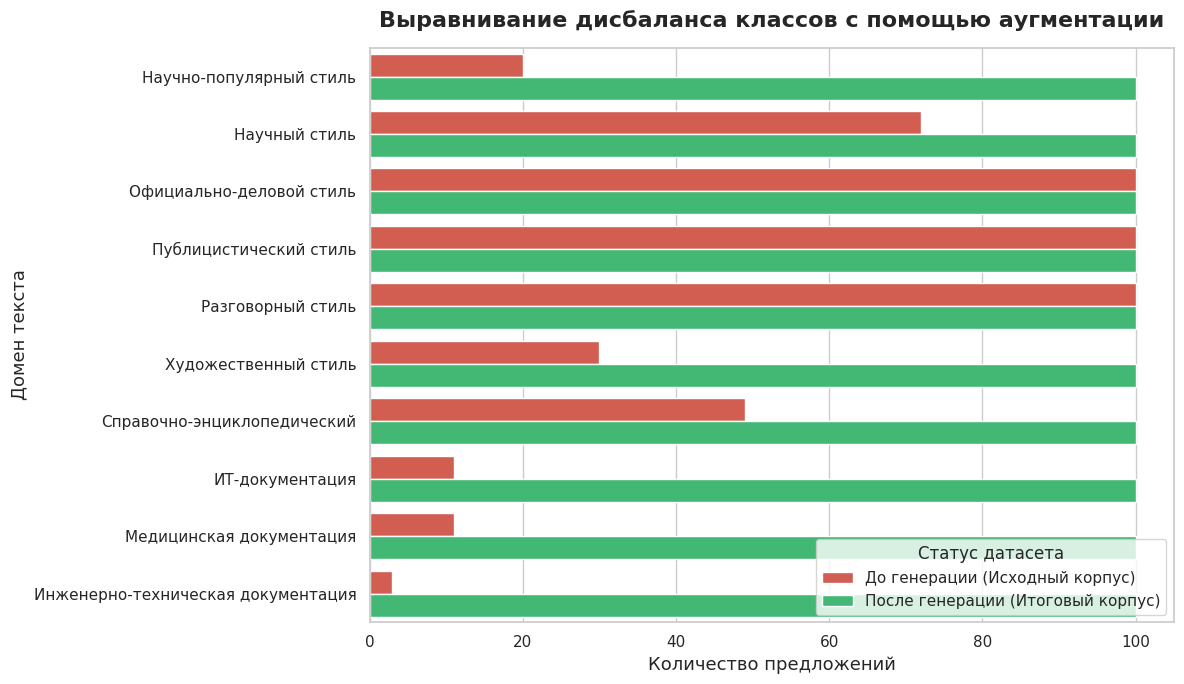

In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Подготовка данных (считаем "До" и "После")
# Данные ДО генерации (только реальные тексты)
before = df[df['is_synthetic'] == False]['domain'].value_counts().reset_index()
before.columns = ['domain', 'count']
before['Этап'] = 'До генерации (Исходный корпус)'

# Данные ПОСЛЕ генерации (реальные + синтетика)
after = df['domain'].value_counts().reset_index()
after.columns = ['domain', 'count']
after['Этап'] = 'После генерации (Итоговый корпус)'

# Объединяем для сгруппированного графика
plot_df = pd.concat([before, after], ignore_index=True)

# Сортируем домены по финальному количеству для красоты
domain_order = after.sort_values(by='count', ascending=False)['domain'].tolist()

# 2. Построение графика
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Строим сгруппированный barplot (по два столбца на домен)
ax = sns.barplot(
    data=plot_df,
    y='domain',
    x='count',
    hue='Этап',
    order=domain_order,
    palette=['#e74c3c', '#2ecc71'] # Красный (проблема) и Зеленый (решение)
)

# 3. Оформление
plt.title('Выравнивание дисбаланса классов с помощью аугментации', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Количество предложений', fontsize=13)
plt.ylabel('Домен текста', fontsize=13)

# Настройка легенды
plt.legend(title='Статус датасета', title_fontsize='12', fontsize='11', loc='lower right')

plt.tight_layout()
plt.savefig('augmentation_before_after.png', dpi=300)
plt.show()

=== ВНУТРИГРУППОВОЙ АНАЛИЗ ТЕХНИЧЕСКИХ ДОМЕНОВ ===
H-статистика Краскела-Уоллиса: 39.01
P-value: 6.93903e-08
✅ Вывод: Домены внутри 'технической' группы СТАТИСТИЧЕСКИ ЗНАЧИМО отличаются друг от друга.
Они не однородны. Необходим адаптивный подход к упрощению.


/tmp/ipykernel_1892/2203787588.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


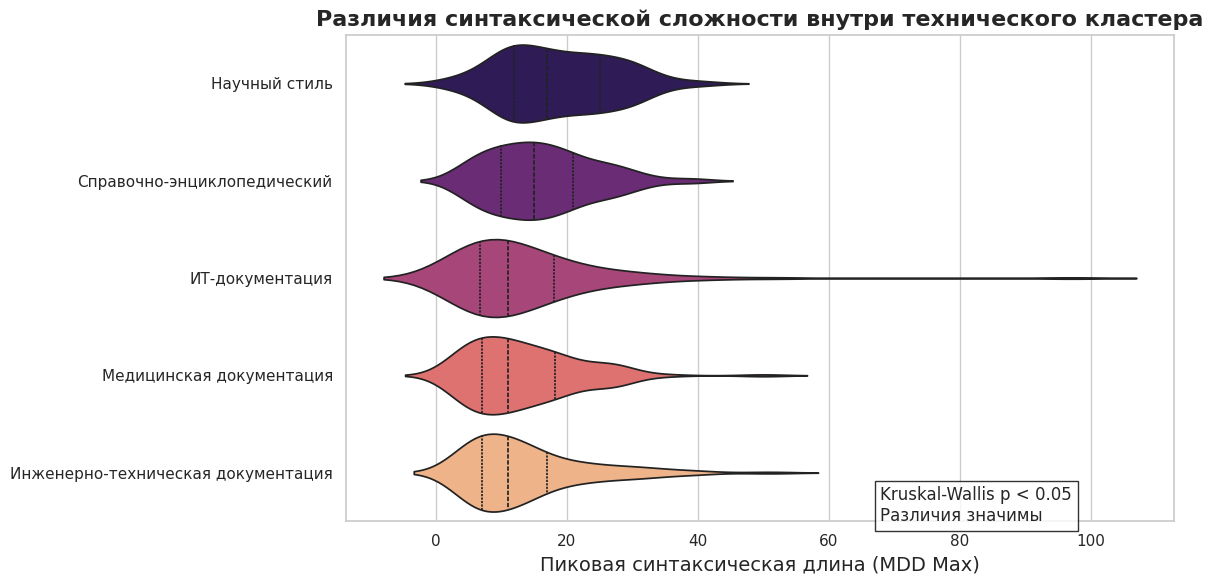

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Выделяем только техническую/сложную группу
tech_domains = [
    "Инженерно-техническая документация",
    "Медицинская документация",
    "ИТ-документация",
    "Научный стиль",
    "Справочно-энциклопедический"
]

df_tech = df[df['domain'].isin(tech_domains)]

# 2. Статистический тест (Краскел-Уоллис для множественного сравнения)
# Собираем данные по mdd_max в список массивов
groups_mdd = [df_tech[df_tech['domain'] == d]['mdd_max'].dropna() for d in tech_domains]
stat, p_value = stats.kruskal(*groups_mdd)

print("=== ВНУТРИГРУППОВОЙ АНАЛИЗ ТЕХНИЧЕСКИХ ДОМЕНОВ ===")
print(f"H-статистика Краскела-Уоллиса: {stat:.2f}")
print(f"P-value: {p_value:.5e}")

if p_value < 0.05:
    print("✅ Вывод: Домены внутри 'технической' группы СТАТИСТИЧЕСКИ ЗНАЧИМО отличаются друг от друга.")
    print("Они не однородны. Необходим адаптивный подход к упрощению.")
else:
    print("❌ Вывод: Домены статистически однородны по данной метрике.")

# 3. Визуализация (Violin Plot для показа формы распределения)
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Violin plot показывает, где концентрируется основная масса предложений
sns.violinplot(
    data=df_tech,
    x='mdd_max',
    y='domain',
    palette='magma',
    inner="quartile" # Показываем медиану и квартили внутри "скрипки"
)

plt.title('Различия синтаксической сложности внутри технического кластера', fontsize=16, fontweight='bold')
plt.xlabel('Пиковая синтаксическая длина (MDD Max)', fontsize=14)
plt.ylabel('', fontsize=14) # Убираем лишнюю подпись оси Y

# Если p-value < 0.05, добавляем эту информацию прямо на график
if p_value < 0.05:
    plt.text(
        df_tech['mdd_max'].max() * 0.7,
        len(tech_domains) - 0.5,
        f"Kruskal-Wallis p < 0.05\nРазличия значимы",
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='black')
    )

plt.tight_layout()
plt.savefig('tech_domains_internal_variance.png', dpi=300)
plt.show()